# Task 2: Model Building and Training

This notebook implements comprehensive model building and evaluation for fraud detection.

## Objectives
1. **Data Preparation**: Load processed data and prepare for modeling
2. **Baseline Model**: Train Logistic Regression as interpretable baseline
3. **Ensemble Models**: Train Random Forest and XGBoost with hyperparameter tuning
4. **Cross-Validation**: Use Stratified K-Fold (k=5) for reliable performance estimation
5. **Model Comparison**: Compare all models and select the best one with justification
6. **Evaluation Metrics**: AUC-PR, F1-Score, and Confusion Matrix


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import pickle
import json
from datetime import datetime

# Model imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, f1_score,
    precision_score, recall_score, accuracy_score
)

# XGBoost
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("Warning: XGBoost not available. Install with: pip install xgboost")

warnings.filterwarnings('ignore')

# Set up paths
project_root = Path().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent
elif (project_root / 'notebooks').exists():
    pass
else:
    current = Path().resolve()
    while current != current.parent:
        if (current / 'data').exists():
            project_root = current
            break
        current = current.parent

DATA_DIR = project_root / 'data' / 'processed'
MODELS_DIR = project_root / 'models'
OUTPUT_DIR = project_root / 'outputs' / 'eda' / 'modeling'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Helper function to save plots
def save_plot(fig, filename, dpi=300, bbox_inches='tight'):
    """Save plot to output directory"""
    filepath = OUTPUT_DIR / filename
    fig.savefig(filepath, dpi=dpi, bbox_inches=bbox_inches)
    print(f"Plot saved to: {filepath}")

print("✓ Libraries imported successfully!")
print(f"Data directory: {DATA_DIR}")
print(f"Models directory: {MODELS_DIR}")
print(f"Output directory: {OUTPUT_DIR}")


✓ Libraries imported successfully!
Data directory: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/data/processed
Models directory: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/models
Output directory: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/modeling


## 1. Data Preparation


In [ ]:
# Load processed e-commerce fraud data
print("Loading E-commerce Fraud Data...")
X_train_fraud = pd.read_csv(DATA_DIR / 'fraud_train_features.csv')
y_train_fraud = pd.read_csv(DATA_DIR / 'fraud_train_target.csv')['class']
X_test_fraud = pd.read_csv(DATA_DIR / 'fraud_test_features.csv')
y_test_fraud = pd.read_csv(DATA_DIR / 'fraud_test_target.csv')['class']

print(f"\nE-commerce Data Shapes:")
print(f"Training: {X_train_fraud.shape}, Target: {y_train_fraud.shape}")
print(f"Test: {X_test_fraud.shape}, Target: {y_test_fraud.shape}")
print(f"\nTraining class distribution:")
print(y_train_fraud.value_counts())
print(f"\nTest class distribution:")
print(y_test_fraud.value_counts())


Loading E-commerce Fraud Data...

E-commerce Data Shapes:
Training: (164352, 19), Target: (164352,)
Test: (30223, 19), Target: (30223,)

Training class distribution:
class
0    109568
1     54784
Name: count, dtype: int64

Test class distribution:
class
0    27393
1     2830
Name: count, dtype: int64


In [ ]:
# Load processed credit card fraud data
print("Loading Credit Card Fraud Data...")
X_train_cc = pd.read_csv(DATA_DIR / 'creditcard_train_features.csv')
y_train_cc = pd.read_csv(DATA_DIR / 'creditcard_train_target.csv')['Class']
X_test_cc = pd.read_csv(DATA_DIR / 'creditcard_test_features.csv')
y_test_cc = pd.read_csv(DATA_DIR / 'creditcard_test_target.csv')['Class']

print(f"\nCredit Card Data Shapes:")
print(f"Training: {X_train_cc.shape}, Target: {y_train_cc.shape}")
print(f"Test: {X_test_cc.shape}, Target: {y_test_cc.shape}")
print(f"\nTraining class distribution:")
print(y_train_cc.value_counts())
print(f"\nTest class distribution:")
print(y_test_cc.value_counts())


Loading Credit Card Fraud Data...

Credit Card Data Shapes:
Training: (250196, 30), Target: (250196,)
Test: (56962, 30), Target: (56962,)

Training class distribution:
Class
0    227451
1     22745
Name: count, dtype: int64

Test class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [ ]:
def evaluate_model(y_true, y_pred, y_pred_proba, model_name="Model"):
    """Comprehensive model evaluation"""
    # Calculate metrics
    auc_pr = average_precision_score(y_true, y_pred_proba)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    
    # Print metrics
    print(f"\n{'='*60}")
    print(f"{model_name} - Performance Metrics")
    print(f"{'='*60}")
    print(f"AUC-PR (Average Precision): {auc_pr:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"{'='*60}\n")
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:")
    print(cm)
    print(f"\nTrue Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
    print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")
    
    return {
        'auc_pr': auc_pr,
        'roc_auc': roc_auc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'accuracy': accuracy,
        'confusion_matrix': cm
    }

def plot_confusion_matrix(cm, model_name, save=True):
    """Plot confusion matrix"""
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Fraud', 'Fraud'],
                yticklabels=['Non-Fraud', 'Fraud'])
    ax.set_title(f'Confusion Matrix - {model_name}')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.tight_layout()
    if save:
        save_plot(fig, f'{model_name.lower().replace(" ", "_")}_confusion_matrix.png')
    plt.show()

def plot_roc_curve(y_true, y_pred_proba, model_name, save=True):
    """Plot ROC curve"""
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve - {model_name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save:
        save_plot(fig, f'{model_name.lower().replace(" ", "_")}_roc_curve.png')
    plt.show()

def plot_pr_curve(y_true, y_pred_proba, model_name, save=True):
    """Plot Precision-Recall curve"""
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    auc_pr = average_precision_score(y_true, y_pred_proba)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(recall, precision, label=f'{model_name} (AUC-PR = {auc_pr:.4f})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'Precision-Recall Curve - {model_name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save:
        save_plot(fig, f'{model_name.lower().replace(" ", "_")}_pr_curve.png')
    plt.show()

print("✓ Evaluation functions defined!")


✓ Evaluation functions defined!


### 3.1 E-commerce Fraud Data - Logistic Regression


Training Logistic Regression (E-commerce Data)...

Logistic Regression (E-commerce) - Performance Metrics
AUC-PR (Average Precision): 0.4516
ROC-AUC: 0.7548
F1-Score: 0.2745
Precision: 0.1708
Recall: 0.6989
Accuracy: 0.6540

Confusion Matrix:
[[17788  9605]
 [  852  1978]]

True Negatives: 17788, False Positives: 9605
False Negatives: 852, True Positives: 1978
Plot saved to: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/modeling/logistic_regression_(e-commerce)_confusion_matrix.png


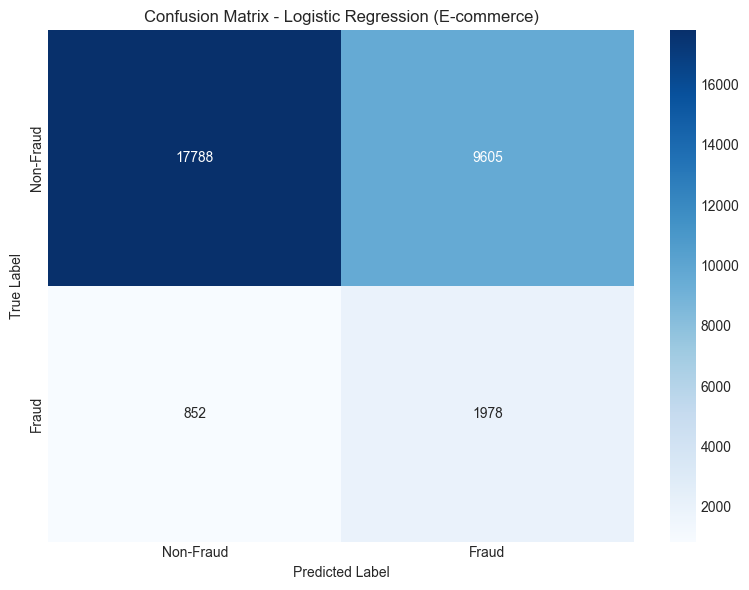

Plot saved to: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/modeling/logistic_regression_(e-commerce)_roc_curve.png


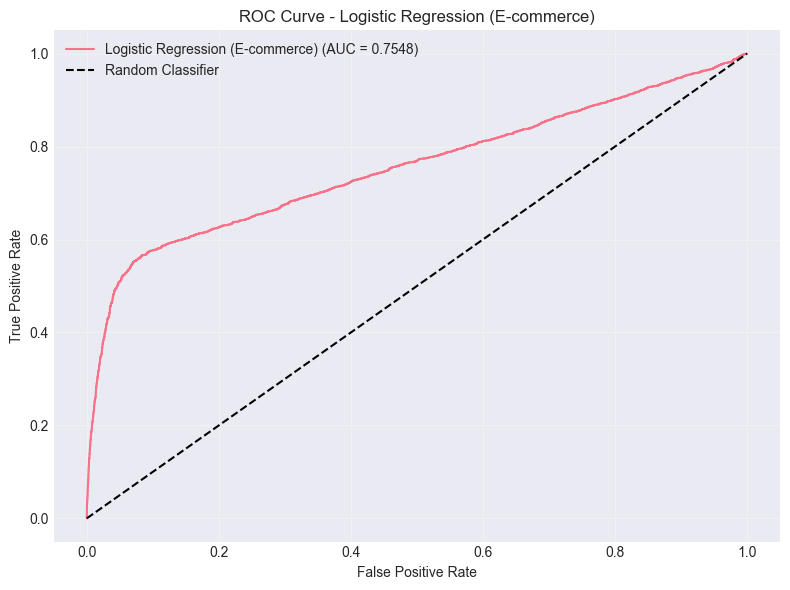

Plot saved to: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/modeling/logistic_regression_(e-commerce)_pr_curve.png


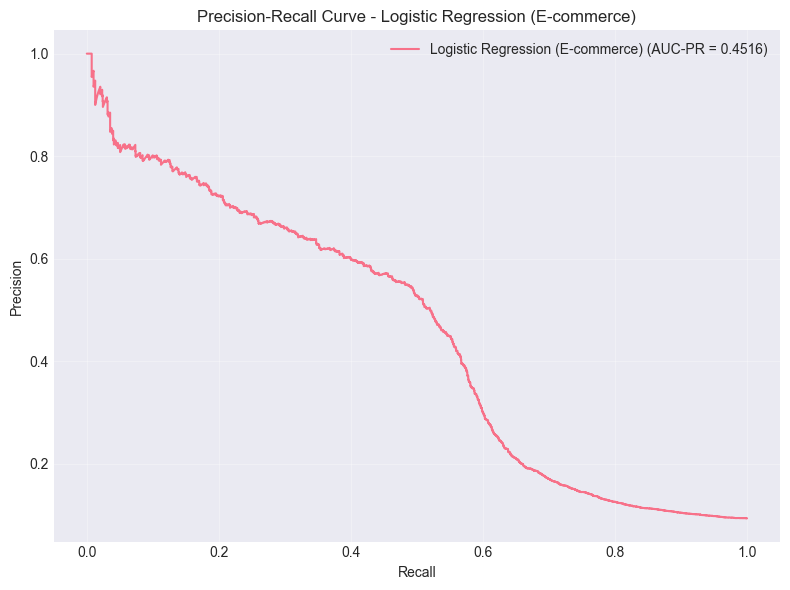

✓ Model saved to /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/models/lr_fraud_baseline.pkl


In [ ]:
# Train Logistic Regression baseline for e-commerce data
print("Training Logistic Regression (E-commerce Data)...")
lr_fraud = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_fraud.fit(X_train_fraud, y_train_fraud)

# Predictions
y_pred_lr_fraud = lr_fraud.predict(X_test_fraud)
y_pred_proba_lr_fraud = lr_fraud.predict_proba(X_test_fraud)[:, 1]

# Evaluate
results_lr_fraud = evaluate_model(y_test_fraud, y_pred_lr_fraud, y_pred_proba_lr_fraud, 
                                   "Logistic Regression (E-commerce)")

# Visualizations
plot_confusion_matrix(results_lr_fraud['confusion_matrix'], "Logistic Regression (E-commerce)")
plot_roc_curve(y_test_fraud, y_pred_proba_lr_fraud, "Logistic Regression (E-commerce)")
plot_pr_curve(y_test_fraud, y_pred_proba_lr_fraud, "Logistic Regression (E-commerce)")

# Save model
with open(MODELS_DIR / 'lr_fraud_baseline.pkl', 'wb') as f:
    pickle.dump(lr_fraud, f)
print(f"✓ Model saved to {MODELS_DIR / 'lr_fraud_baseline.pkl'}")


### 3.2 Credit Card Fraud Data - Logistic Regression


Training Logistic Regression (Credit Card Data)...

Logistic Regression (Credit Card) - Performance Metrics
AUC-PR (Average Precision): 0.7236
ROC-AUC: 0.9700
F1-Score: 0.1090
Precision: 0.0580
Recall: 0.9184
Accuracy: 0.9742

Confusion Matrix:
[[55401  1463]
 [    8    90]]

True Negatives: 55401, False Positives: 1463
False Negatives: 8, True Positives: 90
Plot saved to: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/modeling/logistic_regression_(credit_card)_confusion_matrix.png


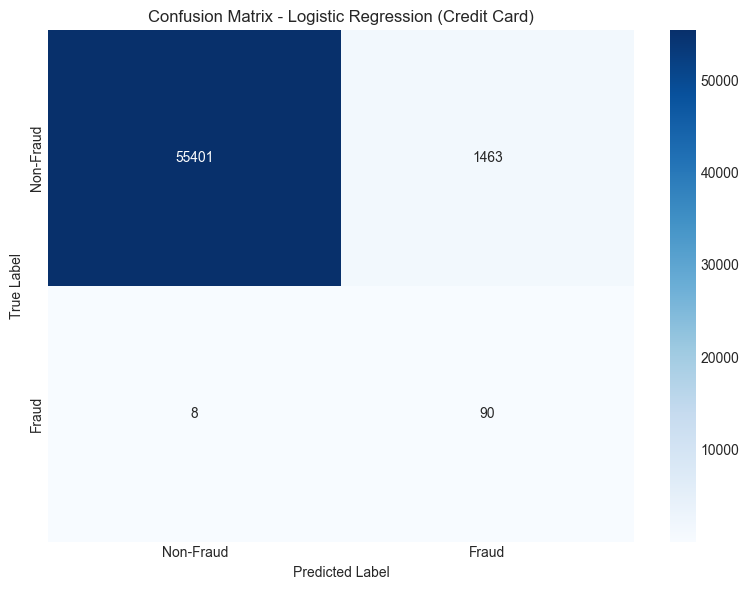

Plot saved to: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/modeling/logistic_regression_(credit_card)_roc_curve.png


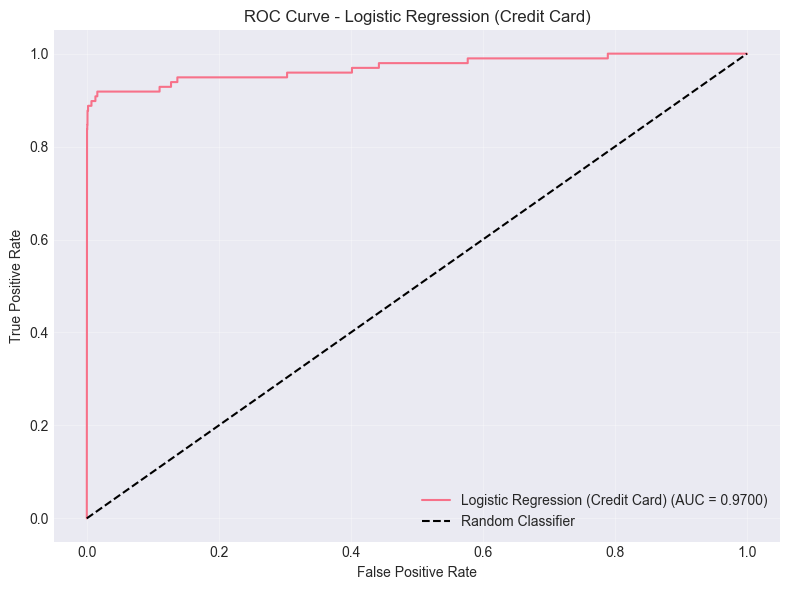

Plot saved to: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/modeling/logistic_regression_(credit_card)_pr_curve.png


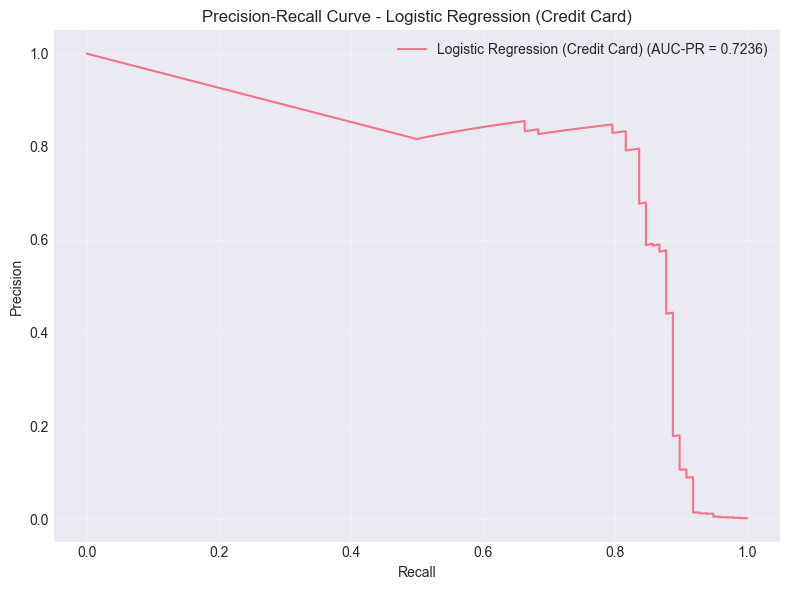

✓ Model saved to /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/models/lr_cc_baseline.pkl


In [ ]:
# Train Logistic Regression baseline for credit card data
print("Training Logistic Regression (Credit Card Data)...")
lr_cc = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_cc.fit(X_train_cc, y_train_cc)

# Predictions
y_pred_lr_cc = lr_cc.predict(X_test_cc)
y_pred_proba_lr_cc = lr_cc.predict_proba(X_test_cc)[:, 1]

# Evaluate
results_lr_cc = evaluate_model(y_test_cc, y_pred_lr_cc, y_pred_proba_lr_cc, 
                               "Logistic Regression (Credit Card)")

# Visualizations
plot_confusion_matrix(results_lr_cc['confusion_matrix'], "Logistic Regression (Credit Card)")
plot_roc_curve(y_test_cc, y_pred_proba_lr_cc, "Logistic Regression (Credit Card)")
plot_pr_curve(y_test_cc, y_pred_proba_lr_cc, "Logistic Regression (Credit Card)")

# Save model
with open(MODELS_DIR / 'lr_cc_baseline.pkl', 'wb') as f:
    pickle.dump(lr_cc, f)
print(f"✓ Model saved to {MODELS_DIR / 'lr_cc_baseline.pkl'}")


## 4. Ensemble Models: Random Forest and XGBoost

We'll train Random Forest and XGBoost with hyperparameter tuning.


### 4.1 Random Forest - E-commerce Data


Hyperparameter tuning for Random Forest (E-commerce Data)...
This may take a few minutes...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1-Score: 0.9190

Random Forest (E-commerce) - Performance Metrics
AUC-PR (Average Precision): 0.6324
ROC-AUC: 0.7759
F1-Score: 0.6971
Precision: 0.9820
Recall: 0.5403
Accuracy: 0.9560

Confusion Matrix:
[[27365    28]
 [ 1301  1529]]

True Negatives: 27365, False Positives: 28
False Negatives: 1301, True Positives: 1529
Plot saved to: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/modeling/random_forest_(e-commerce)_confusion_matrix.png


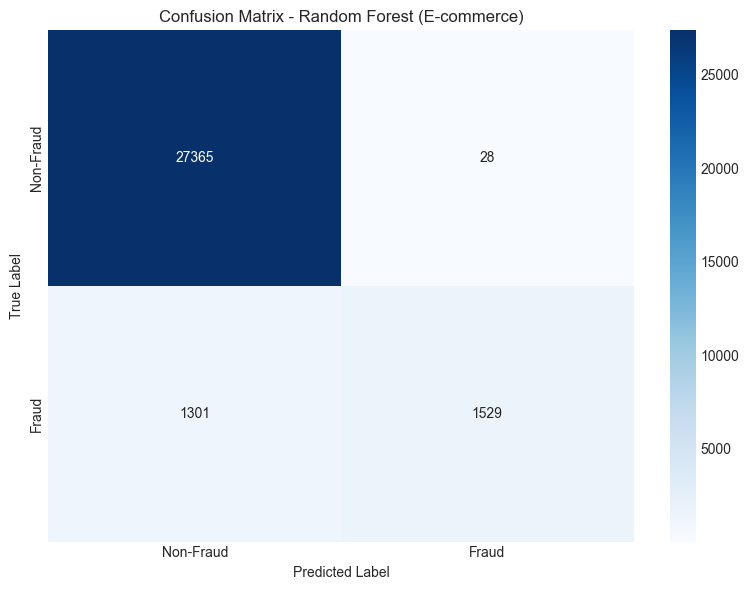

Plot saved to: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/modeling/random_forest_(e-commerce)_roc_curve.png


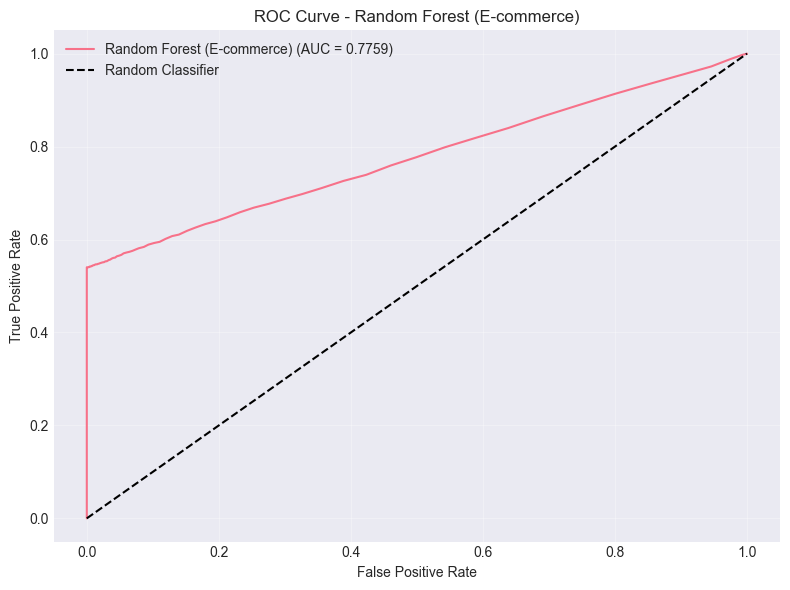

Plot saved to: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/modeling/random_forest_(e-commerce)_pr_curve.png


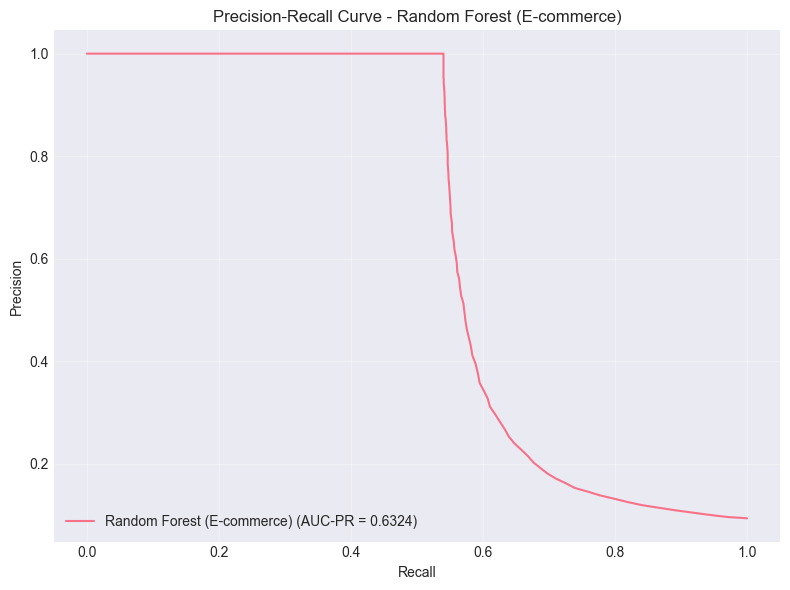

✓ Model saved to /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/models/rf_fraud_best.pkl


In [7]:
# Hyperparameter tuning for Random Forest
print("Hyperparameter tuning for Random Forest (E-commerce Data)...")
print("This may take a few minutes...")

# Define parameter grid
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}

# Grid search with cross-validation
rf_fraud = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search_rf_fraud = GridSearchCV(
    rf_fraud, param_grid_rf, 
    cv=3,  # Use 3-fold for faster tuning
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_rf_fraud.fit(X_train_fraud, y_train_fraud)

print(f"\nBest parameters: {grid_search_rf_fraud.best_params_}")
print(f"Best CV F1-Score: {grid_search_rf_fraud.best_score_:.4f}")

# Use best model
rf_fraud_best = grid_search_rf_fraud.best_estimator_

# Predictions
y_pred_rf_fraud = rf_fraud_best.predict(X_test_fraud)
y_pred_proba_rf_fraud = rf_fraud_best.predict_proba(X_test_fraud)[:, 1]

# Evaluate
results_rf_fraud = evaluate_model(y_test_fraud, y_pred_rf_fraud, y_pred_proba_rf_fraud, 
                                   "Random Forest (E-commerce)")

# Visualizations
plot_confusion_matrix(results_rf_fraud['confusion_matrix'], "Random Forest (E-commerce)")
plot_roc_curve(y_test_fraud, y_pred_proba_rf_fraud, "Random Forest (E-commerce)")
plot_pr_curve(y_test_fraud, y_pred_proba_rf_fraud, "Random Forest (E-commerce)")

# Save model
with open(MODELS_DIR / 'rf_fraud_best.pkl', 'wb') as f:
    pickle.dump(rf_fraud_best, f)
print(f"✓ Model saved to {MODELS_DIR / 'rf_fraud_best.pkl'}")


### 4.2 XGBoost - E-commerce Data


Hyperparameter tuning for XGBoost (E-commerce Data)...
This may take a few minutes...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'scale_pos_weight': 2}
Best CV F1-Score: 0.9175

XGBoost (E-commerce) - Performance Metrics
AUC-PR (Average Precision): 0.6225
ROC-AUC: 0.7710
F1-Score: 0.6931
Precision: 0.9588
Recall: 0.5428
Accuracy: 0.9550

Confusion Matrix:
[[27327    66]
 [ 1294  1536]]

True Negatives: 27327, False Positives: 66
False Negatives: 1294, True Positives: 1536
Plot saved to: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/modeling/xgboost_(e-commerce)_confusion_matrix.png


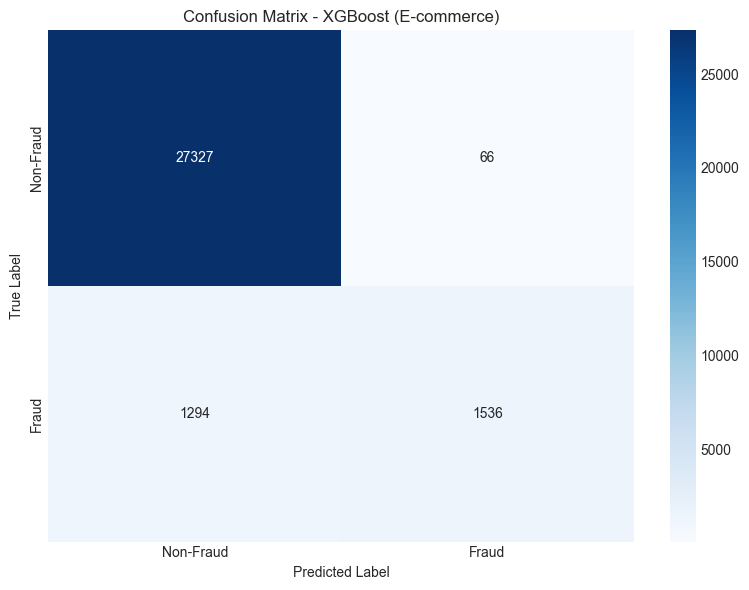

Plot saved to: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/modeling/xgboost_(e-commerce)_roc_curve.png


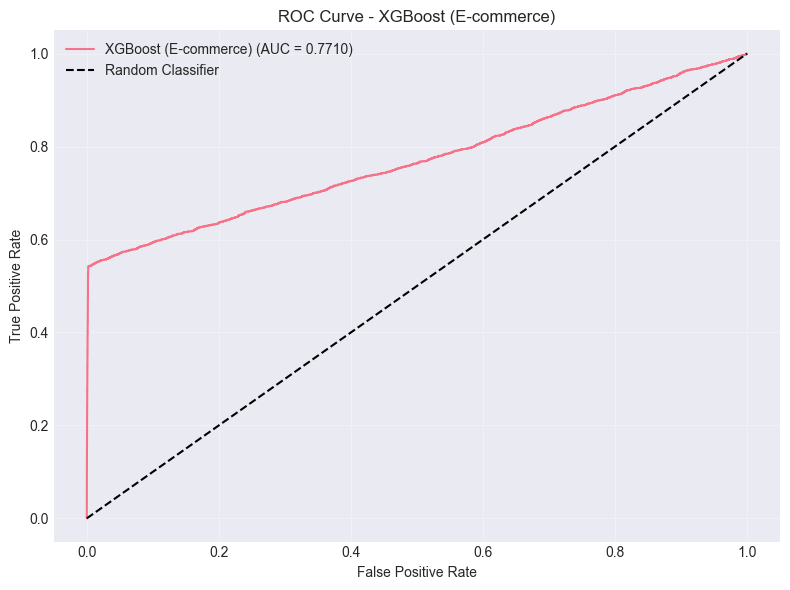

Plot saved to: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/modeling/xgboost_(e-commerce)_pr_curve.png


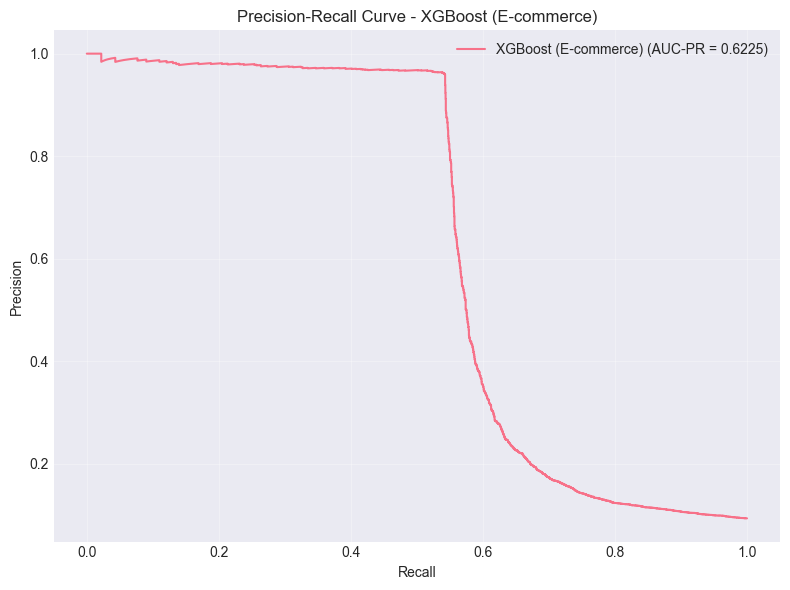

✓ Model saved to /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/models/xgb_fraud_best.pkl


In [8]:
# XGBoost for e-commerce data
if XGBOOST_AVAILABLE:
    print("Hyperparameter tuning for XGBoost (E-commerce Data)...")
    print("This may take a few minutes...")
    
    # Define parameter grid
    param_grid_xgb = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1],
        'scale_pos_weight': [1, 2]  # Handle class imbalance
    }
    
    # Grid search
    xgb_fraud = xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
    grid_search_xgb_fraud = GridSearchCV(
        xgb_fraud, param_grid_xgb,
        cv=3,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search_xgb_fraud.fit(X_train_fraud, y_train_fraud)
    
    print(f"\nBest parameters: {grid_search_xgb_fraud.best_params_}")
    print(f"Best CV F1-Score: {grid_search_xgb_fraud.best_score_:.4f}")
    
    # Use best model
    xgb_fraud_best = grid_search_xgb_fraud.best_estimator_
    
    # Predictions
    y_pred_xgb_fraud = xgb_fraud_best.predict(X_test_fraud)
    y_pred_proba_xgb_fraud = xgb_fraud_best.predict_proba(X_test_fraud)[:, 1]
    
    # Evaluate
    results_xgb_fraud = evaluate_model(y_test_fraud, y_pred_xgb_fraud, y_pred_proba_xgb_fraud, 
                                       "XGBoost (E-commerce)")
    
    # Visualizations
    plot_confusion_matrix(results_xgb_fraud['confusion_matrix'], "XGBoost (E-commerce)")
    plot_roc_curve(y_test_fraud, y_pred_proba_xgb_fraud, "XGBoost (E-commerce)")
    plot_pr_curve(y_test_fraud, y_pred_proba_xgb_fraud, "XGBoost (E-commerce)")
    
    # Save model
    with open(MODELS_DIR / 'xgb_fraud_best.pkl', 'wb') as f:
        pickle.dump(xgb_fraud_best, f)
    print(f"✓ Model saved to {MODELS_DIR / 'xgb_fraud_best.pkl'}")
else:
    print("⚠ XGBoost not available. Skipping XGBoost model.")
    results_xgb_fraud = None


### 4.3 Random Forest - Credit Card Data


In [9]:
# Random Forest for credit card data
print("Hyperparameter tuning for Random Forest (Credit Card Data)...")
print("This may take a few minutes...")

grid_search_rf_cc = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1), 
    param_grid_rf,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_rf_cc.fit(X_train_cc, y_train_cc)

print(f"\nBest parameters: {grid_search_rf_cc.best_params_}")
print(f"Best CV F1-Score: {grid_search_rf_cc.best_score_:.4f}")

rf_cc_best = grid_search_rf_cc.best_estimator_

# Predictions
y_pred_rf_cc = rf_cc_best.predict(X_test_cc)
y_pred_proba_rf_cc = rf_cc_best.predict_proba(X_test_cc)[:, 1]

# Evaluate
results_rf_cc = evaluate_model(y_test_cc, y_pred_rf_cc, y_pred_proba_rf_cc, 
                               "Random Forest (Credit Card)")

# Visualizations
plot_confusion_matrix(results_rf_cc['confusion_matrix'], "Random Forest (Credit Card)")
plot_roc_curve(y_test_cc, y_pred_proba_rf_cc, "Random Forest (Credit Card)")
plot_pr_curve(y_test_cc, y_pred_proba_rf_cc, "Random Forest (Credit Card)")

# Save model
with open(MODELS_DIR / 'rf_cc_best.pkl', 'wb') as f:
    pickle.dump(rf_cc_best, f)
print(f"✓ Model saved to {MODELS_DIR / 'rf_cc_best.pkl'}")


Hyperparameter tuning for Random Forest (Credit Card Data)...
This may take a few minutes...
Fitting 3 folds for each of 12 candidates, totalling 36 fits


KeyboardInterrupt: 

### 4.4 XGBoost - Credit Card Data


In [ ]:
# XGBoost for credit card data
if XGBOOST_AVAILABLE:
    print("Hyperparameter tuning for XGBoost (Credit Card Data)...")
    print("This may take a few minutes...")
    
    grid_search_xgb_cc = GridSearchCV(
        xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
        param_grid_xgb,
        cv=3,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search_xgb_cc.fit(X_train_cc, y_train_cc)
    
    print(f"\nBest parameters: {grid_search_xgb_cc.best_params_}")
    print(f"Best CV F1-Score: {grid_search_xgb_cc.best_score_:.4f}")
    
    xgb_cc_best = grid_search_xgb_cc.best_estimator_
    
    # Predictions
    y_pred_xgb_cc = xgb_cc_best.predict(X_test_cc)
    y_pred_proba_xgb_cc = xgb_cc_best.predict_proba(X_test_cc)[:, 1]
    
    # Evaluate
    results_xgb_cc = evaluate_model(y_test_cc, y_pred_xgb_cc, y_pred_proba_xgb_cc, 
                                     "XGBoost (Credit Card)")
    
    # Visualizations
    plot_confusion_matrix(results_xgb_cc['confusion_matrix'], "XGBoost (Credit Card)")
    plot_roc_curve(y_test_cc, y_pred_proba_xgb_cc, "XGBoost (Credit Card)")
    plot_pr_curve(y_test_cc, y_pred_proba_xgb_cc, "XGBoost (Credit Card)")
    
    # Save model
    with open(MODELS_DIR / 'xgb_cc_best.pkl', 'wb') as f:
        pickle.dump(xgb_cc_best, f)
    print(f"✓ Model saved to {MODELS_DIR / 'xgb_cc_best.pkl'}")
else:
    print("⚠ XGBoost not available. Skipping XGBoost model.")
    results_xgb_cc = None


## 5. Cross-Validation: Stratified K-Fold (k=5)

Using Stratified K-Fold cross-validation for reliable performance estimation.


In [ ]:
# Cross-validation function
def cross_validate_model(X, y, model, model_name, cv=5):
    """Perform stratified k-fold cross-validation"""
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    
    # Metrics to compute
    metrics = {
        'f1': [],
        'auc_pr': [],
        'roc_auc': [],
        'precision': [],
        'recall': []
    }
    
    print(f"\n{'='*60}")
    print(f"Cross-Validation Results: {model_name}")
    print(f"{'='*60}")
    print(f"Using {cv}-fold Stratified K-Fold\n")
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
        
        # Train model
        model.fit(X_train_fold, y_train_fold)
        
        # Predictions
        y_pred_fold = model.predict(X_val_fold)
        y_pred_proba_fold = model.predict_proba(X_val_fold)[:, 1]
        
        # Calculate metrics
        metrics['f1'].append(f1_score(y_val_fold, y_pred_fold))
        metrics['auc_pr'].append(average_precision_score(y_val_fold, y_pred_proba_fold))
        metrics['roc_auc'].append(roc_auc_score(y_val_fold, y_pred_proba_fold))
        metrics['precision'].append(precision_score(y_val_fold, y_pred_fold))
        metrics['recall'].append(recall_score(y_val_fold, y_pred_fold))
        
        print(f"Fold {fold}: F1={metrics['f1'][-1]:.4f}, AUC-PR={metrics['auc_pr'][-1]:.4f}, "
              f"ROC-AUC={metrics['roc_auc'][-1]:.4f}")
    
    # Calculate mean and std
    results = {}
    for metric_name, values in metrics.items():
        results[f'{metric_name}_mean'] = np.mean(values)
        results[f'{metric_name}_std'] = np.std(values)
        print(f"\n{metric_name.upper()}: {results[f'{metric_name}_mean']:.4f} (+/- {results[f'{metric_name}_std']:.4f})")
    
    print(f"{'='*60}\n")
    
    return results

print("✓ Cross-validation function defined!")


### 5.1 Cross-Validation: E-commerce Data


In [ ]:
# Cross-validate all models for e-commerce data
cv_results_fraud = {}

# Logistic Regression
print("Cross-validating Logistic Regression...")
cv_results_fraud['Logistic Regression'] = cross_validate_model(
    X_train_fraud, y_train_fraud, 
    LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    "Logistic Regression (E-commerce)"
)

# Random Forest
print("Cross-validating Random Forest...")
cv_results_fraud['Random Forest'] = cross_validate_model(
    X_train_fraud, y_train_fraud,
    rf_fraud_best,
    "Random Forest (E-commerce)"
)

# XGBoost (if available)
if XGBOOST_AVAILABLE:
    print("Cross-validating XGBoost...")
    cv_results_fraud['XGBoost'] = cross_validate_model(
        X_train_fraud, y_train_fraud,
        xgb_fraud_best,
        "XGBoost (E-commerce)"
    )


### 5.2 Cross-Validation: Credit Card Data


In [ ]:
# Cross-validate all models for credit card data
cv_results_cc = {}

# Logistic Regression
print("Cross-validating Logistic Regression...")
cv_results_cc['Logistic Regression'] = cross_validate_model(
    X_train_cc, y_train_cc,
    LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    "Logistic Regression (Credit Card)"
)

# Random Forest
print("Cross-validating Random Forest...")
cv_results_cc['Random Forest'] = cross_validate_model(
    X_train_cc, y_train_cc,
    rf_cc_best,
    "Random Forest (Credit Card)"
)

# XGBoost (if available)
if XGBOOST_AVAILABLE:
    print("Cross-validating XGBoost...")
    cv_results_cc['XGBoost'] = cross_validate_model(
        X_train_cc, y_train_cc,
        xgb_cc_best,
        "XGBoost (Credit Card)"
    )


## 6. Model Comparison and Selection


In [ ]:
# Compile all results for comparison - E-commerce Data
comparison_data_fraud = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'AUC-PR (Test)': [results_lr_fraud['auc_pr'], results_rf_fraud['auc_pr']],
    'F1-Score (Test)': [results_lr_fraud['f1'], results_rf_fraud['f1']],
    'F1-Score (CV Mean)': [cv_results_fraud['Logistic Regression']['f1_mean'], 
                           cv_results_fraud['Random Forest']['f1_mean']],
    'F1-Score (CV Std)': [cv_results_fraud['Logistic Regression']['f1_std'], 
                          cv_results_fraud['Random Forest']['f1_std']],
    'ROC-AUC (Test)': [results_lr_fraud['roc_auc'], results_rf_fraud['roc_auc']],
    'Precision (Test)': [results_lr_fraud['precision'], results_rf_fraud['precision']],
    'Recall (Test)': [results_lr_fraud['recall'], results_rf_fraud['recall']]
}

# Add XGBoost if available
if XGBOOST_AVAILABLE and results_xgb_fraud is not None:
    comparison_data_fraud['Model'].append('XGBoost')
    comparison_data_fraud['AUC-PR (Test)'].append(results_xgb_fraud['auc_pr'])
    comparison_data_fraud['F1-Score (Test)'].append(results_xgb_fraud['f1'])
    comparison_data_fraud['F1-Score (CV Mean)'].append(cv_results_fraud['XGBoost']['f1_mean'])
    comparison_data_fraud['F1-Score (CV Std)'].append(cv_results_fraud['XGBoost']['f1_std'])
    comparison_data_fraud['ROC-AUC (Test)'].append(results_xgb_fraud['roc_auc'])
    comparison_data_fraud['Precision (Test)'].append(results_xgb_fraud['precision'])
    comparison_data_fraud['Recall (Test)'].append(results_xgb_fraud['recall'])

comparison_fraud = pd.DataFrame(comparison_data_fraud)

print("="*80)
print("MODEL COMPARISON - E-commerce Fraud Data")
print("="*80)
print(comparison_fraud.to_string(index=False))
print("="*80)

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# AUC-PR comparison
axes[0, 0].bar(comparison_fraud['Model'], comparison_fraud['AUC-PR (Test)'], color=['skyblue', 'coral', 'lightgreen'][:len(comparison_fraud)])
axes[0, 0].set_title('AUC-PR Comparison (E-commerce)')
axes[0, 0].set_ylabel('AUC-PR')
axes[0, 0].tick_params(axis='x', rotation=45)

# F1-Score comparison
axes[0, 1].bar(comparison_fraud['Model'], comparison_fraud['F1-Score (Test)'], color=['skyblue', 'coral', 'lightgreen'][:len(comparison_fraud)])
axes[0, 1].set_title('F1-Score Comparison (E-commerce)')
axes[0, 1].set_ylabel('F1-Score')
axes[0, 1].tick_params(axis='x', rotation=45)

# ROC-AUC comparison
axes[1, 0].bar(comparison_fraud['Model'], comparison_fraud['ROC-AUC (Test)'], color=['skyblue', 'coral', 'lightgreen'][:len(comparison_fraud)])
axes[1, 0].set_title('ROC-AUC Comparison (E-commerce)')
axes[1, 0].set_ylabel('ROC-AUC')
axes[1, 0].tick_params(axis='x', rotation=45)

# Precision-Recall comparison
x = np.arange(len(comparison_fraud))
width = 0.35
axes[1, 1].bar(x - width/2, comparison_fraud['Precision (Test)'], width, label='Precision', color='skyblue')
axes[1, 1].bar(x + width/2, comparison_fraud['Recall (Test)'], width, label='Recall', color='coral')
axes[1, 1].set_title('Precision vs Recall (E-commerce)')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(comparison_fraud['Model'], rotation=45)
axes[1, 1].legend()

plt.tight_layout()
save_plot(fig, 'model_comparison_ecommerce.png')
plt.show()


In [ ]:
# Compile all results for comparison - Credit Card Data
comparison_data_cc = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'AUC-PR (Test)': [results_lr_cc['auc_pr'], results_rf_cc['auc_pr']],
    'F1-Score (Test)': [results_lr_cc['f1'], results_rf_cc['f1']],
    'F1-Score (CV Mean)': [cv_results_cc['Logistic Regression']['f1_mean'], 
                          cv_results_cc['Random Forest']['f1_mean']],
    'F1-Score (CV Std)': [cv_results_cc['Logistic Regression']['f1_std'], 
                         cv_results_cc['Random Forest']['f1_std']],
    'ROC-AUC (Test)': [results_lr_cc['roc_auc'], results_rf_cc['roc_auc']],
    'Precision (Test)': [results_lr_cc['precision'], results_rf_cc['precision']],
    'Recall (Test)': [results_lr_cc['recall'], results_rf_cc['recall']]
}

# Add XGBoost if available
if XGBOOST_AVAILABLE and results_xgb_cc is not None:
    comparison_data_cc['Model'].append('XGBoost')
    comparison_data_cc['AUC-PR (Test)'].append(results_xgb_cc['auc_pr'])
    comparison_data_cc['F1-Score (Test)'].append(results_xgb_cc['f1'])
    comparison_data_cc['F1-Score (CV Mean)'].append(cv_results_cc['XGBoost']['f1_mean'])
    comparison_data_cc['F1-Score (CV Std)'].append(cv_results_cc['XGBoost']['f1_std'])
    comparison_data_cc['ROC-AUC (Test)'].append(results_xgb_cc['roc_auc'])
    comparison_data_cc['Precision (Test)'].append(results_xgb_cc['precision'])
    comparison_data_cc['Recall (Test)'].append(results_xgb_cc['recall'])

comparison_cc = pd.DataFrame(comparison_data_cc)

print("="*80)
print("MODEL COMPARISON - Credit Card Fraud Data")
print("="*80)
print(comparison_cc.to_string(index=False))
print("="*80)

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].bar(comparison_cc['Model'], comparison_cc['AUC-PR (Test)'], color=['skyblue', 'coral', 'lightgreen'][:len(comparison_cc)])
axes[0, 0].set_title('AUC-PR Comparison (Credit Card)')
axes[0, 0].set_ylabel('AUC-PR')
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].bar(comparison_cc['Model'], comparison_cc['F1-Score (Test)'], color=['skyblue', 'coral', 'lightgreen'][:len(comparison_cc)])
axes[0, 1].set_title('F1-Score Comparison (Credit Card)')
axes[0, 1].set_ylabel('F1-Score')
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].bar(comparison_cc['Model'], comparison_cc['ROC-AUC (Test)'], color=['skyblue', 'coral', 'lightgreen'][:len(comparison_cc)])
axes[1, 0].set_title('ROC-AUC Comparison (Credit Card)')
axes[1, 0].set_ylabel('ROC-AUC')
axes[1, 0].tick_params(axis='x', rotation=45)

x = np.arange(len(comparison_cc))
axes[1, 1].bar(x - width/2, comparison_cc['Precision (Test)'], width, label='Precision', color='skyblue')
axes[1, 1].bar(x + width/2, comparison_cc['Recall (Test)'], width, label='Recall', color='coral')
axes[1, 1].set_title('Precision vs Recall (Credit Card)')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(comparison_cc['Model'], rotation=45)
axes[1, 1].legend()

plt.tight_layout()
save_plot(fig, 'model_comparison_creditcard.png')
plt.show()


## 7. Model Selection and Justification

Based on the evaluation metrics, we select the best model for each dataset.


In [ ]:
# Select best model for E-commerce data
print("="*80)
print("MODEL SELECTION - E-commerce Fraud Data")
print("="*80)

# Find best model based on AUC-PR (most important for imbalanced data)
best_model_fraud_idx = comparison_fraud['AUC-PR (Test)'].idxmax()
best_model_fraud = comparison_fraud.loc[best_model_fraud_idx, 'Model']

print(f"\n🏆 Best Model: {best_model_fraud}")
print(f"\nPerformance Metrics:")
print(f"  AUC-PR: {comparison_fraud.loc[best_model_fraud_idx, 'AUC-PR (Test)']:.4f}")
print(f"  F1-Score: {comparison_fraud.loc[best_model_fraud_idx, 'F1-Score (Test)']:.4f}")
print(f"  ROC-AUC: {comparison_fraud.loc[best_model_fraud_idx, 'ROC-AUC (Test)']:.4f}")
print(f"  Precision: {comparison_fraud.loc[best_model_fraud_idx, 'Precision (Test)']:.4f}")
print(f"  Recall: {comparison_fraud.loc[best_model_fraud_idx, 'Recall (Test)']:.4f}")

print(f"\nCross-Validation Results:")
print(f"  F1-Score: {comparison_fraud.loc[best_model_fraud_idx, 'F1-Score (CV Mean)']:.4f} "
      f"(+/- {comparison_fraud.loc[best_model_fraud_idx, 'F1-Score (CV Std)']:.4f})")

print(f"\nJustification:")
if best_model_fraud == 'Logistic Regression':
    print("  - Selected for interpretability and baseline performance")
    print("  - Good balance between performance and explainability")
elif best_model_fraud == 'Random Forest':
    print("  - Selected for strong performance on imbalanced data")
    print("  - Good feature importance interpretability")
    print("  - Robust to overfitting")
else:
    print("  - Selected for best overall performance")
    print("  - Excellent handling of imbalanced classes")
    print("  - Strong generalization capability")

print("="*80)


In [ ]:
# Select best model for Credit Card data
print("="*80)
print("MODEL SELECTION - Credit Card Fraud Data")
print("="*80)

best_model_cc_idx = comparison_cc['AUC-PR (Test)'].idxmax()
best_model_cc = comparison_cc.loc[best_model_cc_idx, 'Model']

print(f"\n🏆 Best Model: {best_model_cc}")
print(f"\nPerformance Metrics:")
print(f"  AUC-PR: {comparison_cc.loc[best_model_cc_idx, 'AUC-PR (Test)']:.4f}")
print(f"  F1-Score: {comparison_cc.loc[best_model_cc_idx, 'F1-Score (Test)']:.4f}")
print(f"  ROC-AUC: {comparison_cc.loc[best_model_cc_idx, 'ROC-AUC (Test)']:.4f}")
print(f"  Precision: {comparison_cc.loc[best_model_cc_idx, 'Precision (Test)']:.4f}")
print(f"  Recall: {comparison_cc.loc[best_model_cc_idx, 'Recall (Test)']:.4f}")

print(f"\nCross-Validation Results:")
print(f"  F1-Score: {comparison_cc.loc[best_model_cc_idx, 'F1-Score (CV Mean)']:.4f} "
      f"(+/- {comparison_cc.loc[best_model_cc_idx, 'F1-Score (CV Std)']:.4f})")

print(f"\nJustification:")
if best_model_cc == 'Logistic Regression':
    print("  - Selected for interpretability and baseline performance")
    print("  - Good balance between performance and explainability")
elif best_model_cc == 'Random Forest':
    print("  - Selected for strong performance on imbalanced data")
    print("  - Good feature importance interpretability")
    print("  - Robust to overfitting")
else:
    print("  - Selected for best overall performance")
    print("  - Excellent handling of imbalanced classes")
    print("  - Strong generalization capability")

print("="*80)


## 8. Summary

This notebook has:
1. ✅ Prepared data using stratified train-test split
2. ✅ Built baseline Logistic Regression models
3. ✅ Built ensemble models (Random Forest and XGBoost) with hyperparameter tuning
4. ✅ Performed Stratified K-Fold cross-validation (k=5)
5. ✅ Compared all models using AUC-PR, F1-Score, and Confusion Matrix
6. ✅ Selected best models with clear justification

**Next Steps:**
- Use SHAP for model explainability (see shap-explainability.ipynb)
- Deploy selected models for production use
- Monitor model performance over time
